In [22]:
import logging

import torch

import specter
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.pdb import PDB
from specter.plots import plot3d, plot_particle_stack
from specter.potential import PotentialBuilder
from specter.progress import track
from specter.cryosparc import extract_parameters_from_csfile
from specter.ice import IceBank

import mrcfile

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
specter.set_verbosity(logging.INFO)

## Required parameters

In [3]:
n = 256  # number of pixels in image
pdb_code = "6bdf"
dose_per_angstrom = 53  # e-/A^2, from EMDB Experiment tab.
num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame

## Specify .cs from CryoSPARC Job that contains rotations and aberrations

In [12]:
cs_path = "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/J35_passthrough_particles.cs"
n_particles = 10  # set to None for all.
(
    energy_kev,
    pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
    split,
) = extract_parameters_from_csfile(cs_path, n_particles=n_particles)
rotations.shape

torch.Size([10, 4])

## Generate particle scattering potential

In [6]:
# fetch pdb file
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [7]:
# Samples 3D scattering potential onto specified grid
device = "cpu"
pb = PotentialBuilder(n, pixel_size.item(), pdb.atomic_numbers).to(device)

In [8]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

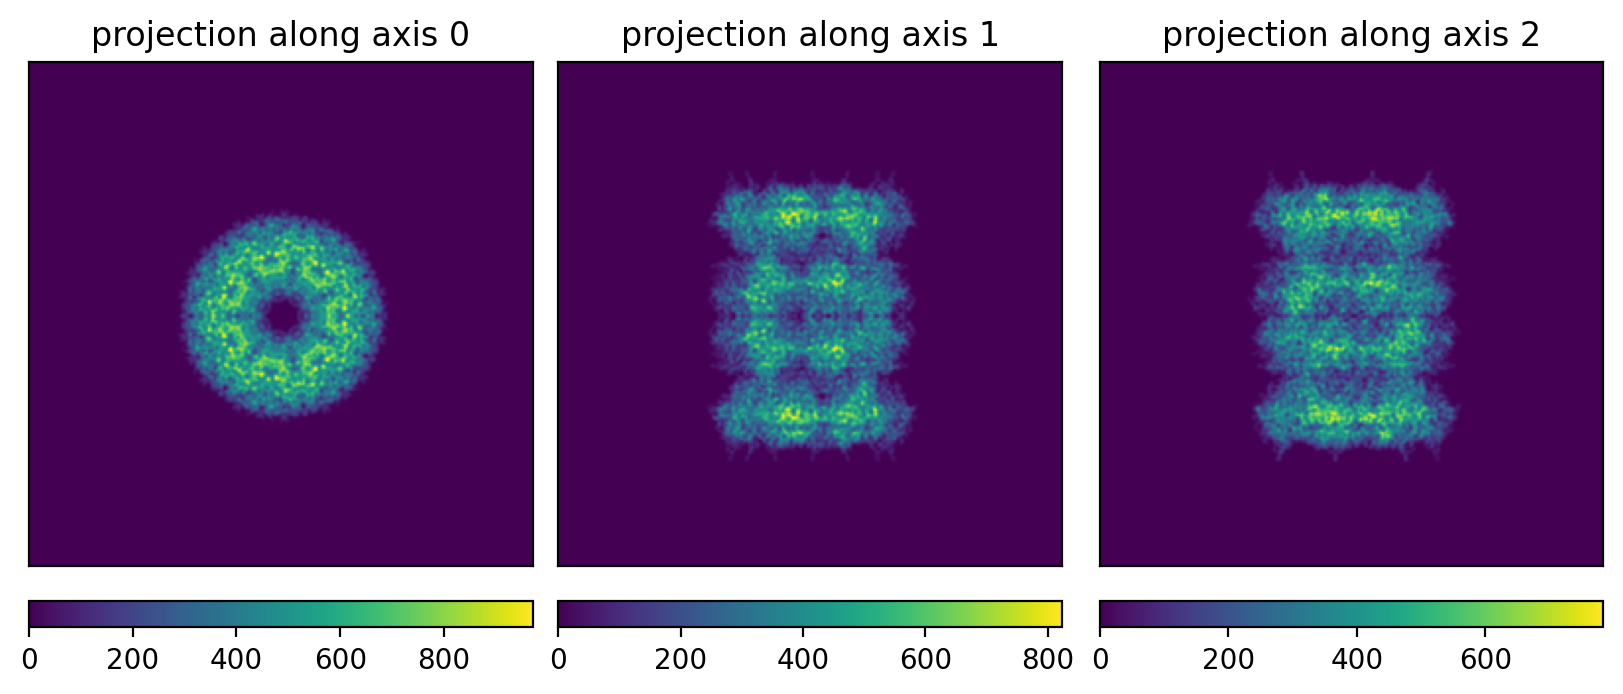

In [9]:
plot3d(V)

## Generate particles
Note: adjust ```coincidence_radius``` to match the contrast of your simulated images to the experiments.

In [13]:
# n_particles = len(rotations)  # number of particles
device = "cuda:0"  # choose cpu if you run out of cuda memory.

In [16]:
# Build the bank once — move to GPU before building
# method:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
bank = IceBank(dx=pixel_size, n=256, method="gd", num_unique=8).to(device)
bank.build()

Building ice cubes (method: gradient descent):   0%|          | 0/8 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

L-BFGS for ice coordinates:   0%|          | 0/50 [00:00<?, ?it/s]

In [36]:
# Scattering model: 'multislice', 'firstborn', 'projection', 'ctf'
scattering_model = "multislice"

# Aberration model: 'holography' or 'ctf'
aberration_model = "holography"

# Noise model: 'poisson' or None
noise_model = "poisson"
# noise_model = None

# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = 2.0

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

detector_model = None
# detector_model = "perfect"  # 'perfect', 'k3_300kv', 'k3_200kv'

bfactor = 200.0

model = ImageGenerator(
    V,
    pixel_size.item(),
    rotations,
    translations_A,
    ctf_params,
    energy_kev,
    dose_per_angstrom,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    icemaker=bank,
    bfactor=bfactor,
).to(device)

In [37]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/2 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/10 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/8 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/9 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/8 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

torch.Size([10, 256, 256])

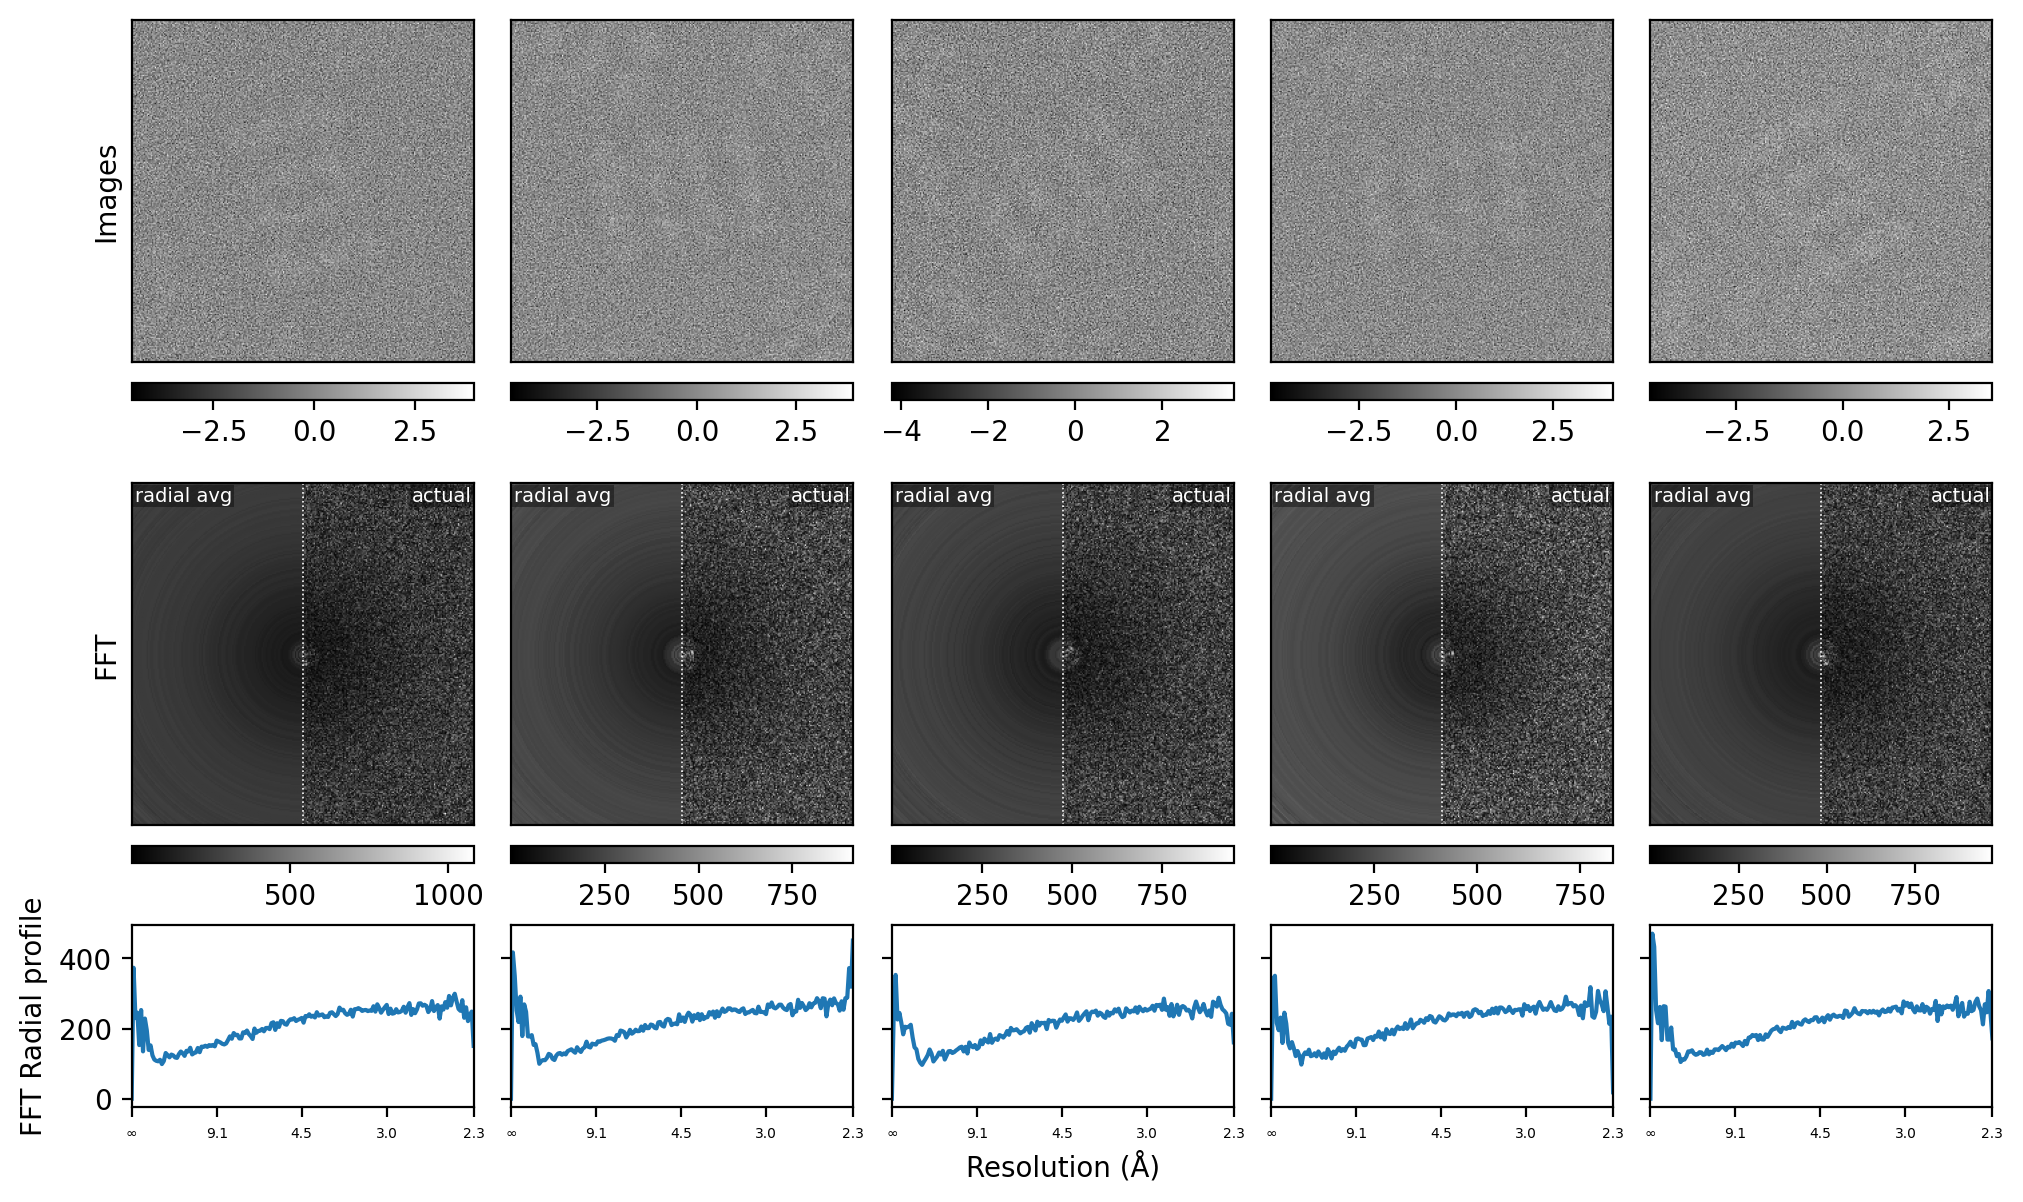

In [38]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

plot_particle_stack(particles, pixel_size)

## Compare with experimental particles (if available)

In [31]:
with mrcfile.mmap(
    "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"
) as mrc:
    exp = torch.as_tensor(mrc.data[indices].copy())

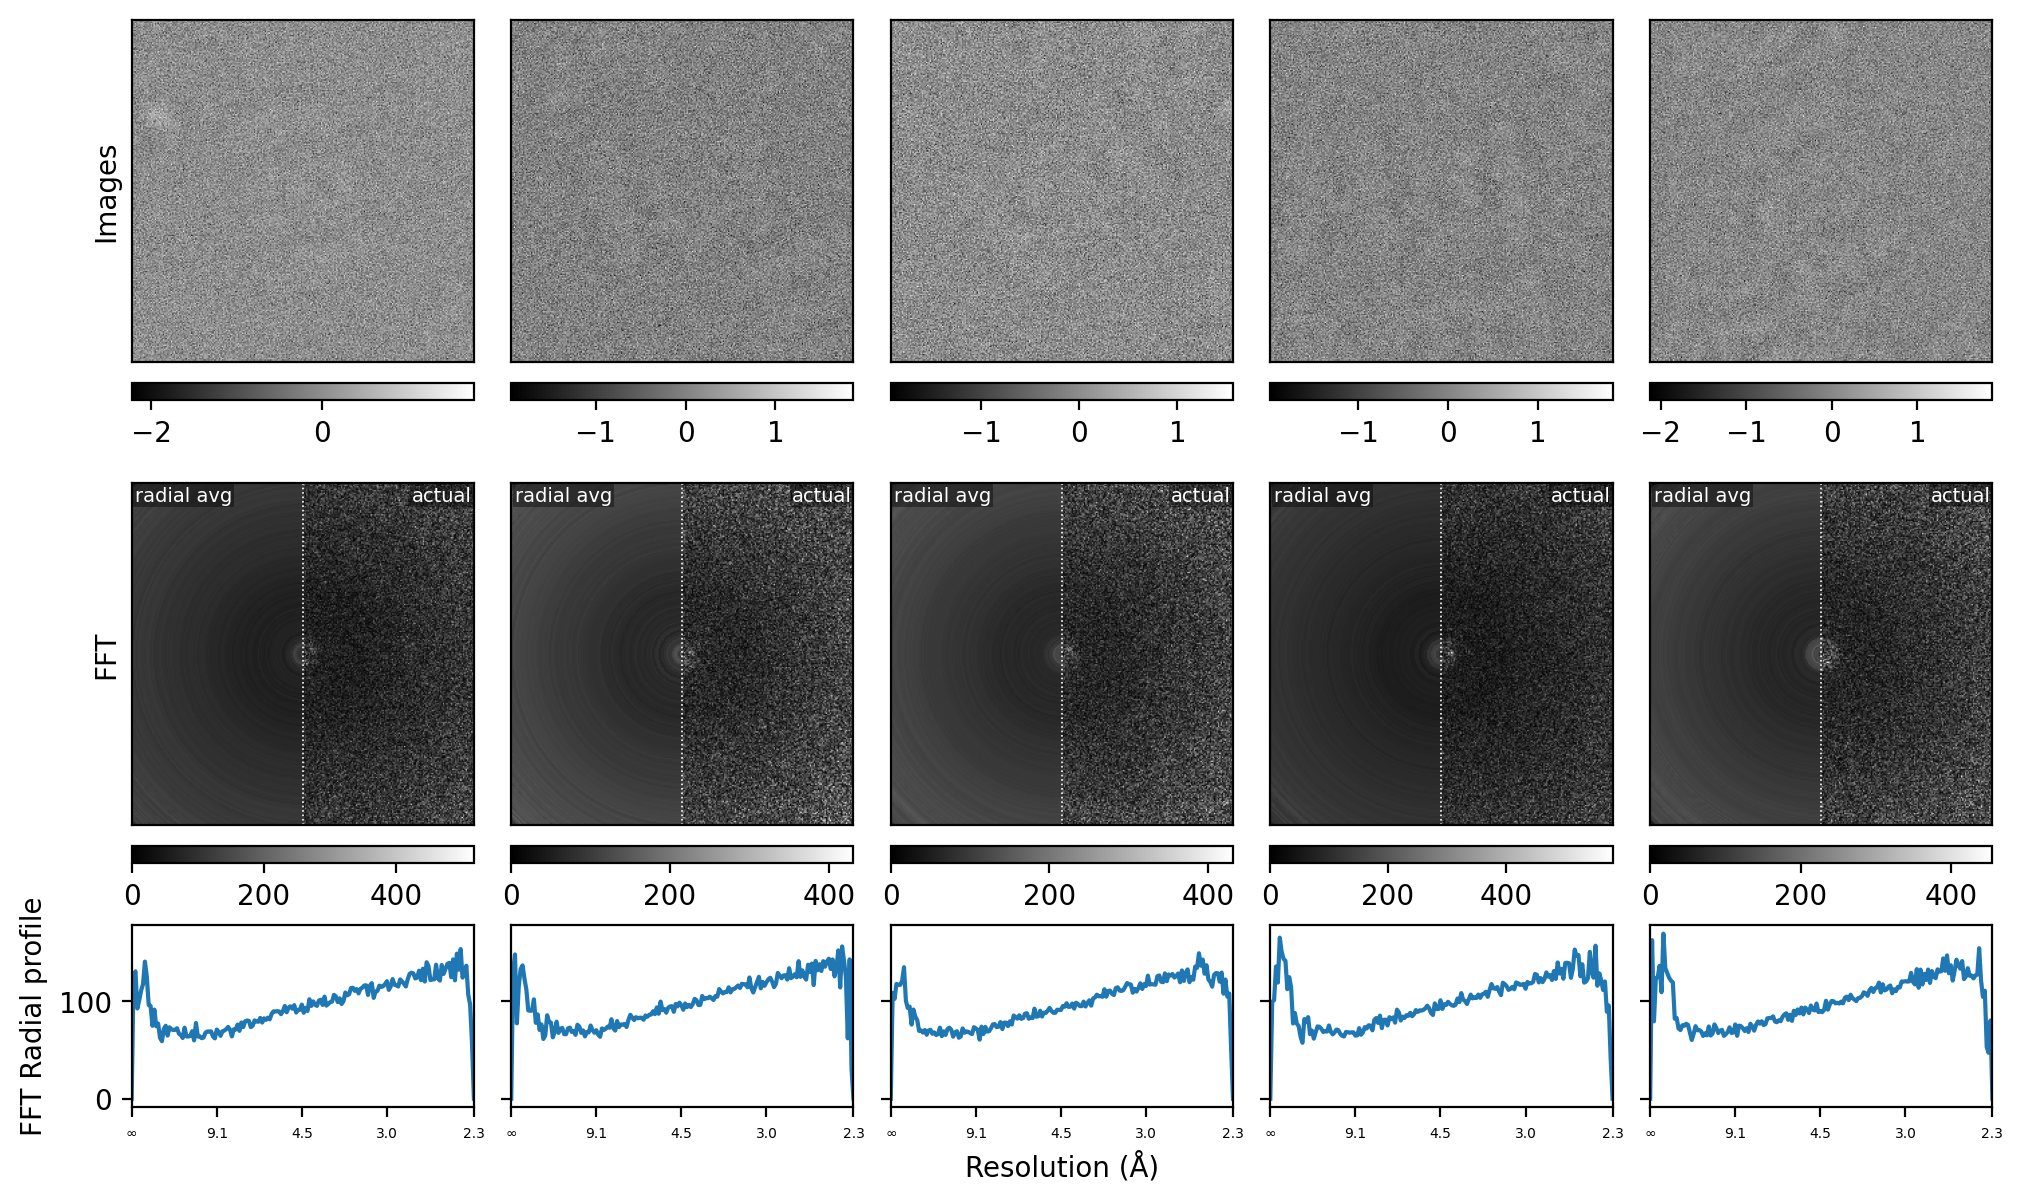

In [35]:
plot_particle_stack(exp, pixel_size)